# VGG16 Batik Classification - Simplified Training

**Fitur Utama:**
- Preprocessing sederhana
- VGG16 Pretrained Model (Transfer Learning)
- Opsi Split Dataset: 60/20/20, 70/15/15, 80/10/10, 90/5/5, 98/1/1
- Training langsung tanpa ribet

**Dataset: 111 Kelas Batik Nusantara**

## Setup & Imports

In [17]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import pandas as pd
from torch.cuda.amp import autocast, GradScaler  # Mixed Precision Training

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"✅ Mixed Precision Training: ENABLED")
    print(f"✅ Optimized for RTX 3060")    

Device: cuda
GPU: NVIDIA GeForce RTX 3060
CUDA Version: 12.8
GPU Memory: 11.63 GB
✅ Mixed Precision Training: ENABLED
✅ Optimized for RTX 3060


## Split Dataset

Pilih rasio split dataset antara train/val/test

In [18]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# Dataset source
SOURCE_DIR = 'data'  # Folder dengan subfolder per kelas

# Opsi split ratio: train/val/test
SPLIT_OPTIONS = {
    '60/20/20': (0.60, 0.20, 0.20),
    '70/15/15': (0.70, 0.15, 0.15),
    '80/10/10': (0.80, 0.10, 0.10),
    '90/5/5': (0.90, 0.05, 0.05),
    '98/1/1': (0.98, 0.01, 0.01)
}

# PILIH SPLIT RATIO DI SINI
SELECTED_SPLIT = '60/20/20'  # Ubah sesuai kebutuhan
train_ratio, val_ratio, test_ratio = SPLIT_OPTIONS[SELECTED_SPLIT]

print(f"Split Ratio: {SELECTED_SPLIT}")
print(f"Train: {train_ratio*100}% | Val: {val_ratio*100}% | Test: {test_ratio*100}%")


def split_dataset(source_dir, train_ratio, val_ratio, test_ratio):
    """Split dataset ke train/val/test"""
    
    # Buat folder output
    output_dirs = {
        'train': Path('data/train'),
        'val': Path('data/val'),
        'test': Path('data/test')
    }
    
    # Hapus folder lama jika ada
    for dir_path in output_dirs.values():
        if dir_path.exists():
            shutil.rmtree(dir_path)
        dir_path.mkdir(parents=True, exist_ok=True)
    
    source_path = Path(source_dir)
    
    # Loop setiap kelas
    class_folders = [f for f in source_path.iterdir() if f.is_dir() 
                    and f.name not in ['train', 'val', 'test']]
    
    total_images = 0
    split_counts = {'train': 0, 'val': 0, 'test': 0}
    
    for class_folder in tqdm(class_folders, desc='Splitting dataset'):
        class_name = class_folder.name
        
        # Buat folder untuk kelas ini di train/val/test
        for split_name, split_dir in output_dirs.items():
            (split_dir / class_name).mkdir(exist_ok=True)
        
        # Ambil semua gambar di kelas ini
        image_files = list(class_folder.glob('*.*'))
        image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        
        if len(image_files) == 0:
            continue
        
        # Split data
        train_files, temp_files = train_test_split(
            image_files, 
            train_size=train_ratio, 
            random_state=42
        )
        
        # Split temp ke val dan test
        val_size_adjusted = val_ratio / (val_ratio + test_ratio)
        val_files, test_files = train_test_split(
            temp_files, 
            train_size=val_size_adjusted, 
            random_state=42
        )
        
        # Copy files
        for img in train_files:
            shutil.copy2(img, output_dirs['train'] / class_name / img.name)
        for img in val_files:
            shutil.copy2(img, output_dirs['val'] / class_name / img.name)
        for img in test_files:
            shutil.copy2(img, output_dirs['test'] / class_name / img.name)
        
        split_counts['train'] += len(train_files)
        split_counts['val'] += len(val_files)
        split_counts['test'] += len(test_files)
        total_images += len(image_files)
    
    print(f"\n✅ Dataset Split Complete!")
    print(f"Total Images: {total_images}")
    print(f"Train: {split_counts['train']} ({split_counts['train']/total_images*100:.1f}%)")
    print(f"Val: {split_counts['val']} ({split_counts['val']/total_images*100:.1f}%)")
    print(f"Test: {split_counts['test']} ({split_counts['test']/total_images*100:.1f}%)")
    
    return output_dirs

# Jalankan split dataset
output_dirs = split_dataset(SOURCE_DIR, train_ratio, val_ratio, test_ratio)

Split Ratio: 60/20/20
Train: 60.0% | Val: 20.0% | Test: 20.0%


Splitting dataset: 100%|██████████| 111/111 [01:28<00:00,  1.25it/s]


✅ Dataset Split Complete!
Total Images: 111685
Train: 66947 (59.9%)
Val: 22360 (20.0%)
Test: 22378 (20.0%)


## Preprocessing - Simple Transforms

In [19]:
IMAGE_SIZE = 224
BATCH_SIZE = 64  # Optimized for RTX 3060 (12GB VRAM)

# Preprocessing untuk training (dengan augmentasi)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Preprocessing untuk validation & test (tanpa augmentasi)
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder('data/train', transform=train_transforms)
val_dataset = datasets.ImageFolder('data/val', transform=val_transforms)
test_dataset = datasets.ImageFolder('data/test', transform=val_transforms)

# DataLoaders - Optimized for speed
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=8,  # Increased for faster data loading
    pin_memory=True,  # Faster GPU transfer
    persistent_workers=True,  # Keep workers alive
    prefetch_factor=2  # Prefetch batches
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print(f"Classes: {num_classes}")
print(f"Training: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Classes: 111
Training: 66947 images
Validation: 22360 images
Test: 22378 images


## VGG16 Pretrained Model

In [20]:
# Load VGG16 pretrained
model = models.vgg16(pretrained=True)

# Freeze feature layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier untuk jumlah kelas kita
num_features = model.classifier[0].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, num_classes)
)

model = model.to(device)

# Compile model for faster training (PyTorch 2.0+)
try:
    model = torch.compile(model)
    print("✅ Model compiled with torch.compile")
except:
    print("⚠️ torch.compile not available (requires PyTorch 2.0+)")

print(f"Model: VGG16 Pretrained")
print(f"Output Classes: {num_classes}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


/home/rim/MYSELF/PROJECT/PBL/Model-PCVK/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rim/MYSELF/PROJECT/PBL/Model-PCVK/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Model compiled with torch.compile
Model: VGG16 Pretrained
Output Classes: 111
Trainable params: 103,219,311


## Training Configuration

In [21]:
EPOCHS = 30
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Mixed Precision Scaler
scaler = GradScaler()

print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Loss: CrossEntropyLoss")
print(f"Mixed Precision: ENABLED (2-3x faster on RTX 3060)")

Epochs: 30
Learning Rate: 0.001
Optimizer: Adam
Loss: CrossEntropyLoss
Mixed Precision: ENABLED (2-3x faster on RTX 3060)


/tmp/ipykernel_80917/1523441325.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## Training Loop

In [22]:
history = {
    'train_loss': [], 'train_acc': [], 
    'val_loss': [], 'val_acc': [],
    'epoch_time': [], 'learning_rate': []
}
best_acc = 0.0
best_epoch = 0

# Training start time
training_start_time = time.time()
print(f"Training Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    
    # TRAINING
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Mixed Precision Training
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = 100. * train_correct / train_total
    
    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            # Mixed Precision for validation too
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = 100. * val_correct / val_total
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time
    
    # Update history - PERBAIKAN: append semua metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    # Learning rate scheduler
    scheduler.step(val_acc)
    
    # Print results
    print(f"\nEpoch {epoch+1}/{EPOCHS} - Time: {epoch_time:.2f}s")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_acc:
        improvement = val_acc - best_acc
        best_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
            'class_names': class_names,
            'history': history
        }, 'vgg16_batik_best.pth')
        print(f"  ✅ New Best: {best_acc:.2f}% (↑{improvement:.2f}%)")
    print("-"*70)

# Training end time
total_training_time = time.time() - training_start_time
avg_epoch_time = np.mean(history['epoch_time'])

print("="*70)
print(f"Training Complete!")
print(f"Training Ended: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Training Time: {total_training_time/3600:.2f} hours ({total_training_time/60:.2f} minutes)")

print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Best Validation Accuracy: {best_acc:.2f}% (Epoch {best_epoch})")
print("="*70)
print(f"Best Validation Accuracy: {best_acc:.2f}% (Epoch {best_epoch})")
print(f"Total Training Time: {total_training_time/3600:.2f} hours ({total_training_time/60:.2f} minutes)")
print(f"Best Validation Accuracy: {best_acc:.2f}% (Epoch {best_epoch})")


Training Started: 2025-11-30 02:09:13


Epoch 1/30 [Train]:   0%|          | 0/1047 [00:00<?, ?it/s]/tmp/ipykernel_80917/3569231608.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/30 [Train]:   0%|          | 1/1047 [00:01<24:58,  1.43s/it]/tmp/ipykernel_80917/3569231608.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/30 [Val]:   0%|          | 0/350 [00:00<?, ?it/s]/tmp/ipykernel_80917/3569231608.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/30 [Val]:   0%|          | 1/350 [00:00<05:33,  1.05it/s]/tmp/ipykernel_80917/3569231608.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/30 [Val]: 100%|███


Epoch 1/30 - Time: 228.94s
  Train - Loss: 0.8505, Acc: 80.03%
  Val   - Loss: 0.1902, Acc: 94.83%
  LR: 0.001000
  ✅ New Best: 94.83% (↑94.83%)
----------------------------------------------------------------------
  ✅ New Best: 94.83% (↑94.83%)
----------------------------------------------------------------------


Epoch 2/30 [Val]: 100%|██████████| 350/350 [00:46<00:00,  7.60it/s]




Epoch 2/30 - Time: 220.68s
  Train - Loss: 0.5267, Acc: 88.47%
  Val   - Loss: 0.1488, Acc: 96.39%
  LR: 0.001000
  ✅ New Best: 96.39% (↑1.56%)
----------------------------------------------------------------------
  ✅ New Best: 96.39% (↑1.56%)
----------------------------------------------------------------------


...


Epoch 28/30 - Time: 215.57s
  Train - Loss: 0.1797, Acc: 98.82%
  Val   - Loss: 0.2011, Acc: 99.15%
  LR: 0.000500
----------------------------------------------------------------------


Epoch 29/30 [Val]: 100%|██████████| 350/350 [00:45<00:00,  7.65it/s]



Epoch 29/30 - Time: 215.40s
  Train - Loss: 0.1635, Acc: 98.90%
  Val   - Loss: 0.1976, Acc: 99.20%
  LR: 0.000500
----------------------------------------------------------------------


Epoch 30/30 [Val]: 100%|██████████| 350/350 [00:45<00:00,  7.65it/s]




Epoch 30/30 - Time: 215.31s
  Train - Loss: 0.1591, Acc: 98.93%
  Val   - Loss: 0.1717, Acc: 99.28%
  LR: 0.000500
  ✅ New Best: 99.28% (↑0.04%)
----------------------------------------------------------------------
Training Complete!
Training Ended: 2025-11-30 03:58:00
Total Training Time: 1.81 hours (108.79 minutes)
Average Time per Epoch: 214.75 seconds
Best Validation Accuracy: 99.28% (Epoch 30)
Best Validation Accuracy: 99.28% (Epoch 30)
Total Training Time: 1.81 hours (108.79 minutes)
Best Validation Accuracy: 99.28% (Epoch 30)
  ✅ New Best: 99.28% (↑0.04%)
----------------------------------------------------------------------
Training Complete!
Training Ended: 2025-11-30 03:58:00
Total Training Time: 1.81 hours (108.79 minutes)
Average Time per Epoch: 214.75 seconds
Best Validation Accuracy: 99.28% (Epoch 30)
Best Validation Accuracy: 99.28% (Epoch 30)
Total Training Time: 1.81 hours (108.79 minutes)
Best Validation Accuracy: 99.28% (Epoch 30)


## Evaluation on Test Set

In [23]:
# Load best model
checkpoint = torch.load('vgg16_batik_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Test evaluation with detailed metrics
model.eval()
test_correct = 0
test_total = 0
all_predictions = []
all_labels = []
all_probabilities = []

test_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

test_time = time.time() - test_start_time
test_acc = 100. * test_correct / test_total

# Calculate detailed metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_predictions, average='weighted', zero_division=0
)

print("="*70)
print("FINAL TEST RESULTS")
print("="*70)
print(f"Test Set Size: {test_total} images")
print(f"Test Time: {test_time:.2f} seconds")
print(f"Inference Speed: {test_total/test_time:.2f} images/second")
print()
print(f"Test Accuracy: {test_acc:.4f}%")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print()
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print(f"Best Epoch: {best_epoch}")
print("="*70)

Testing: 100%|██████████| 350/350 [01:21<00:00,  4.30it/s]

FINAL TEST RESULTS
Test Set Size: 22378 images
Test Time: 81.33 seconds
Inference Speed: 275.16 images/second

Test Accuracy: 99.2850%
Precision (weighted): 0.9929
Recall (weighted): 0.9929
F1-Score (weighted): 0.9928

Best Validation Accuracy: 99.28%
Best Epoch: 30


## Training History Visualization

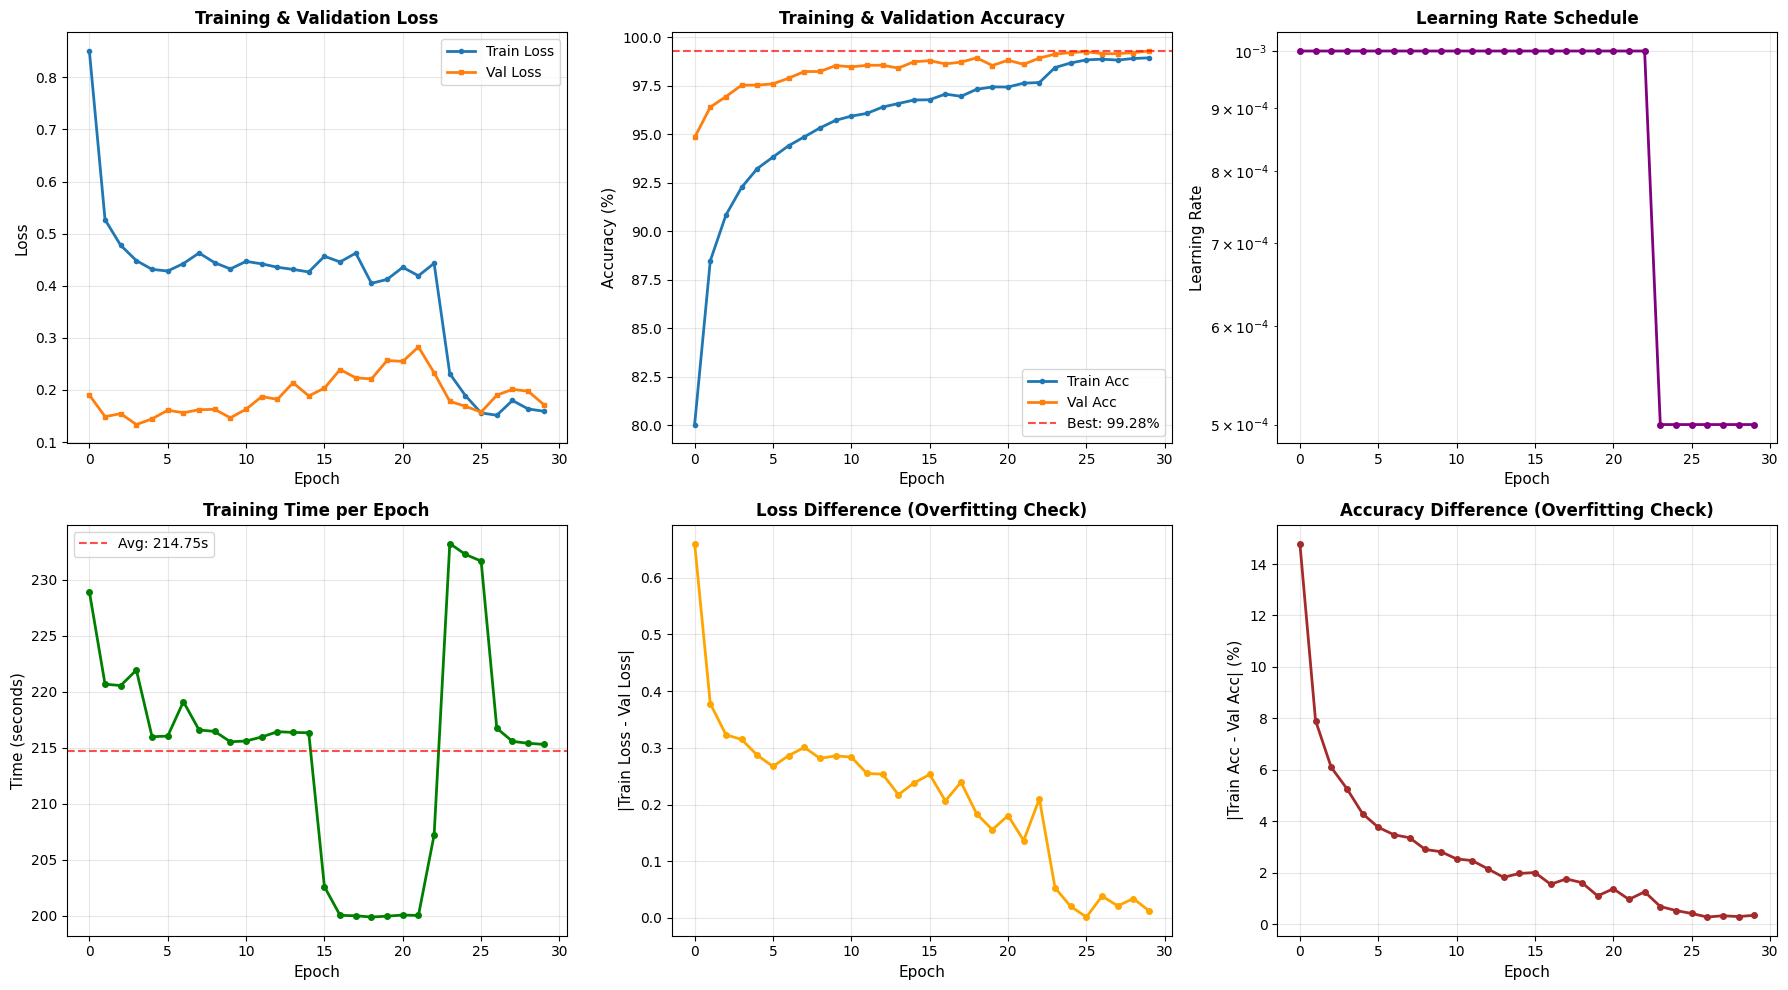

✅ Training history saved as 'training_history_detailed.png'


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2, marker='o', markersize=3)
axes[0, 1].plot(history['val_acc'], label='Val Acc', linewidth=2, marker='s', markersize=3)
axes[0, 1].axhline(y=best_acc, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_acc:.2f}%')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 1].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Learning Rate
axes[0, 2].plot(history['learning_rate'], linewidth=2, color='purple', marker='o', markersize=4)
axes[0, 2].set_xlabel('Epoch', fontsize=11)
axes[0, 2].set_ylabel('Learning Rate', fontsize=11)
axes[0, 2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[0, 2].set_yscale('log')
axes[0, 2].grid(True, alpha=0.3)

# 4. Epoch Time
axes[1, 0].plot(history['epoch_time'], linewidth=2, color='green', marker='o', markersize=4)
axes[1, 0].axhline(y=avg_epoch_time, color='red', linestyle='--', alpha=0.7, 
                   label=f'Avg: {avg_epoch_time:.2f}s')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Time (seconds)', fontsize=11)
axes[1, 0].set_title('Training Time per Epoch', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 5. Loss Difference (Overfitting indicator)
loss_diff = [abs(t - v) for t, v in zip(history['train_loss'], history['val_loss'])]
axes[1, 1].plot(loss_diff, linewidth=2, color='orange', marker='o', markersize=4)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('|Train Loss - Val Loss|', fontsize=11)
axes[1, 1].set_title('Loss Difference (Overfitting Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 6. Accuracy Difference
acc_diff = [abs(t - v) for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 2].plot(acc_diff, linewidth=2, color='brown', marker='o', markersize=4)
axes[1, 2].set_xlabel('Epoch', fontsize=11)
axes[1, 2].set_ylabel('|Train Acc - Val Acc| (%)', fontsize=11)
axes[1, 2].set_title('Accuracy Difference (Overfitting Check)', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history saved as 'training_history_detailed.png'")

## Overfitting Diagnosis

In [25]:
# Analisis Overfitting
print("="*70)
print("OVERFITTING ANALYSIS")
print("="*70)

# Calculate final gap
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
acc_gap = final_train_acc - final_val_acc

final_train_loss = history['train_loss'][-1]
final_val_loss = history['val_loss'][-1]
loss_gap = abs(final_train_loss - final_val_loss)

print(f"\n{'FINAL METRICS':-^70}")
print(f"Final Train Accuracy: {final_train_acc:.2f}%")
print(f"Final Val Accuracy: {final_val_acc:.2f}%")
print(f"Accuracy Gap: {acc_gap:.2f}% {'⚠️ HIGH' if acc_gap > 5 else '✅ OK'}")
print()
print(f"Final Train Loss: {final_train_loss:.4f}")
print(f"Final Val Loss: {final_val_loss:.4f}")
print(f"Loss Gap: {loss_gap:.4f} {'⚠️ HIGH' if loss_gap > 0.1 else '✅ OK'}")

# Check if overfitting
print(f"\n{'OVERFITTING INDICATORS':-^70}")
is_overfitting = False
reasons = []

if acc_gap > 5:
    is_overfitting = True
    reasons.append(f"Train-Val Accuracy Gap: {acc_gap:.2f}% (threshold: >5%)")

if loss_gap > 0.1:
    is_overfitting = True
    reasons.append(f"Train-Val Loss Gap: {loss_gap:.4f} (threshold: >0.1)")

# Check if val loss is increasing while train loss decreasing
if len(history['val_loss']) > 5:
    recent_val_loss_trend = np.mean(history['val_loss'][-5:]) - np.mean(history['val_loss'][-10:-5])
    recent_train_loss_trend = np.mean(history['train_loss'][-5:]) - np.mean(history['train_loss'][-10:-5])
    
    if recent_val_loss_trend > 0 and recent_train_loss_trend < 0:
        is_overfitting = True
        reasons.append("Val loss increasing while train loss decreasing")

if is_overfitting:
    print("🔴 OVERFITTING DETECTED!")
    print("\nReasons:")
    for i, reason in enumerate(reasons, 1):
        print(f"  {i}. {reason}")
    
    print(f"\n{'RECOMMENDED SOLUTIONS':-^70}")
    print("1. Data Augmentation - Tambah augmentasi lebih agresif")
    print("   • Random rotation, color jitter, blur")
    print("   • Mixup/Cutout augmentation")
    print()
    print("2. Regularization - Tambah regularisasi pada model")
    print("   • Increase Dropout: 0.5 → 0.6 atau 0.7")
    print("   • Add Weight Decay: optimizer dengan weight_decay=1e-4")
    print()
    print("3. Early Stopping - Stop training lebih awal")
    print(f"   • Best epoch: {best_epoch}, tapi trained sampai {len(history['train_acc'])}")
    print(f"   • Bisa stop di epoch ~{best_epoch + 5}")
    print()
    print("4. Reduce Model Complexity")
    print("   • Freeze lebih banyak layers VGG16")
    print("   • Reduce classifier size: 4096 → 2048")
else:
    print("✅ NO SIGNIFICANT OVERFITTING")
    print(f"\nTrain-Val Gap: {acc_gap:.2f}% (healthy threshold: <5%)")
    print(f"Model is generalizing well!")

print("="*70)

OVERFITTING ANALYSIS

----------------------------FINAL METRICS-----------------------------
Final Train Accuracy: 98.93%
Final Val Accuracy: 99.28%
Accuracy Gap: -0.35% ✅ OK

Final Train Loss: 0.1591
Final Val Loss: 0.1717
Loss Gap: 0.0126 ✅ OK

------------------------OVERFITTING INDICATORS------------------------
✅ NO SIGNIFICANT OVERFITTING

Train-Val Gap: -0.35% (healthy threshold: <5%)
Model is generalizing well!


## Confusion Matrix

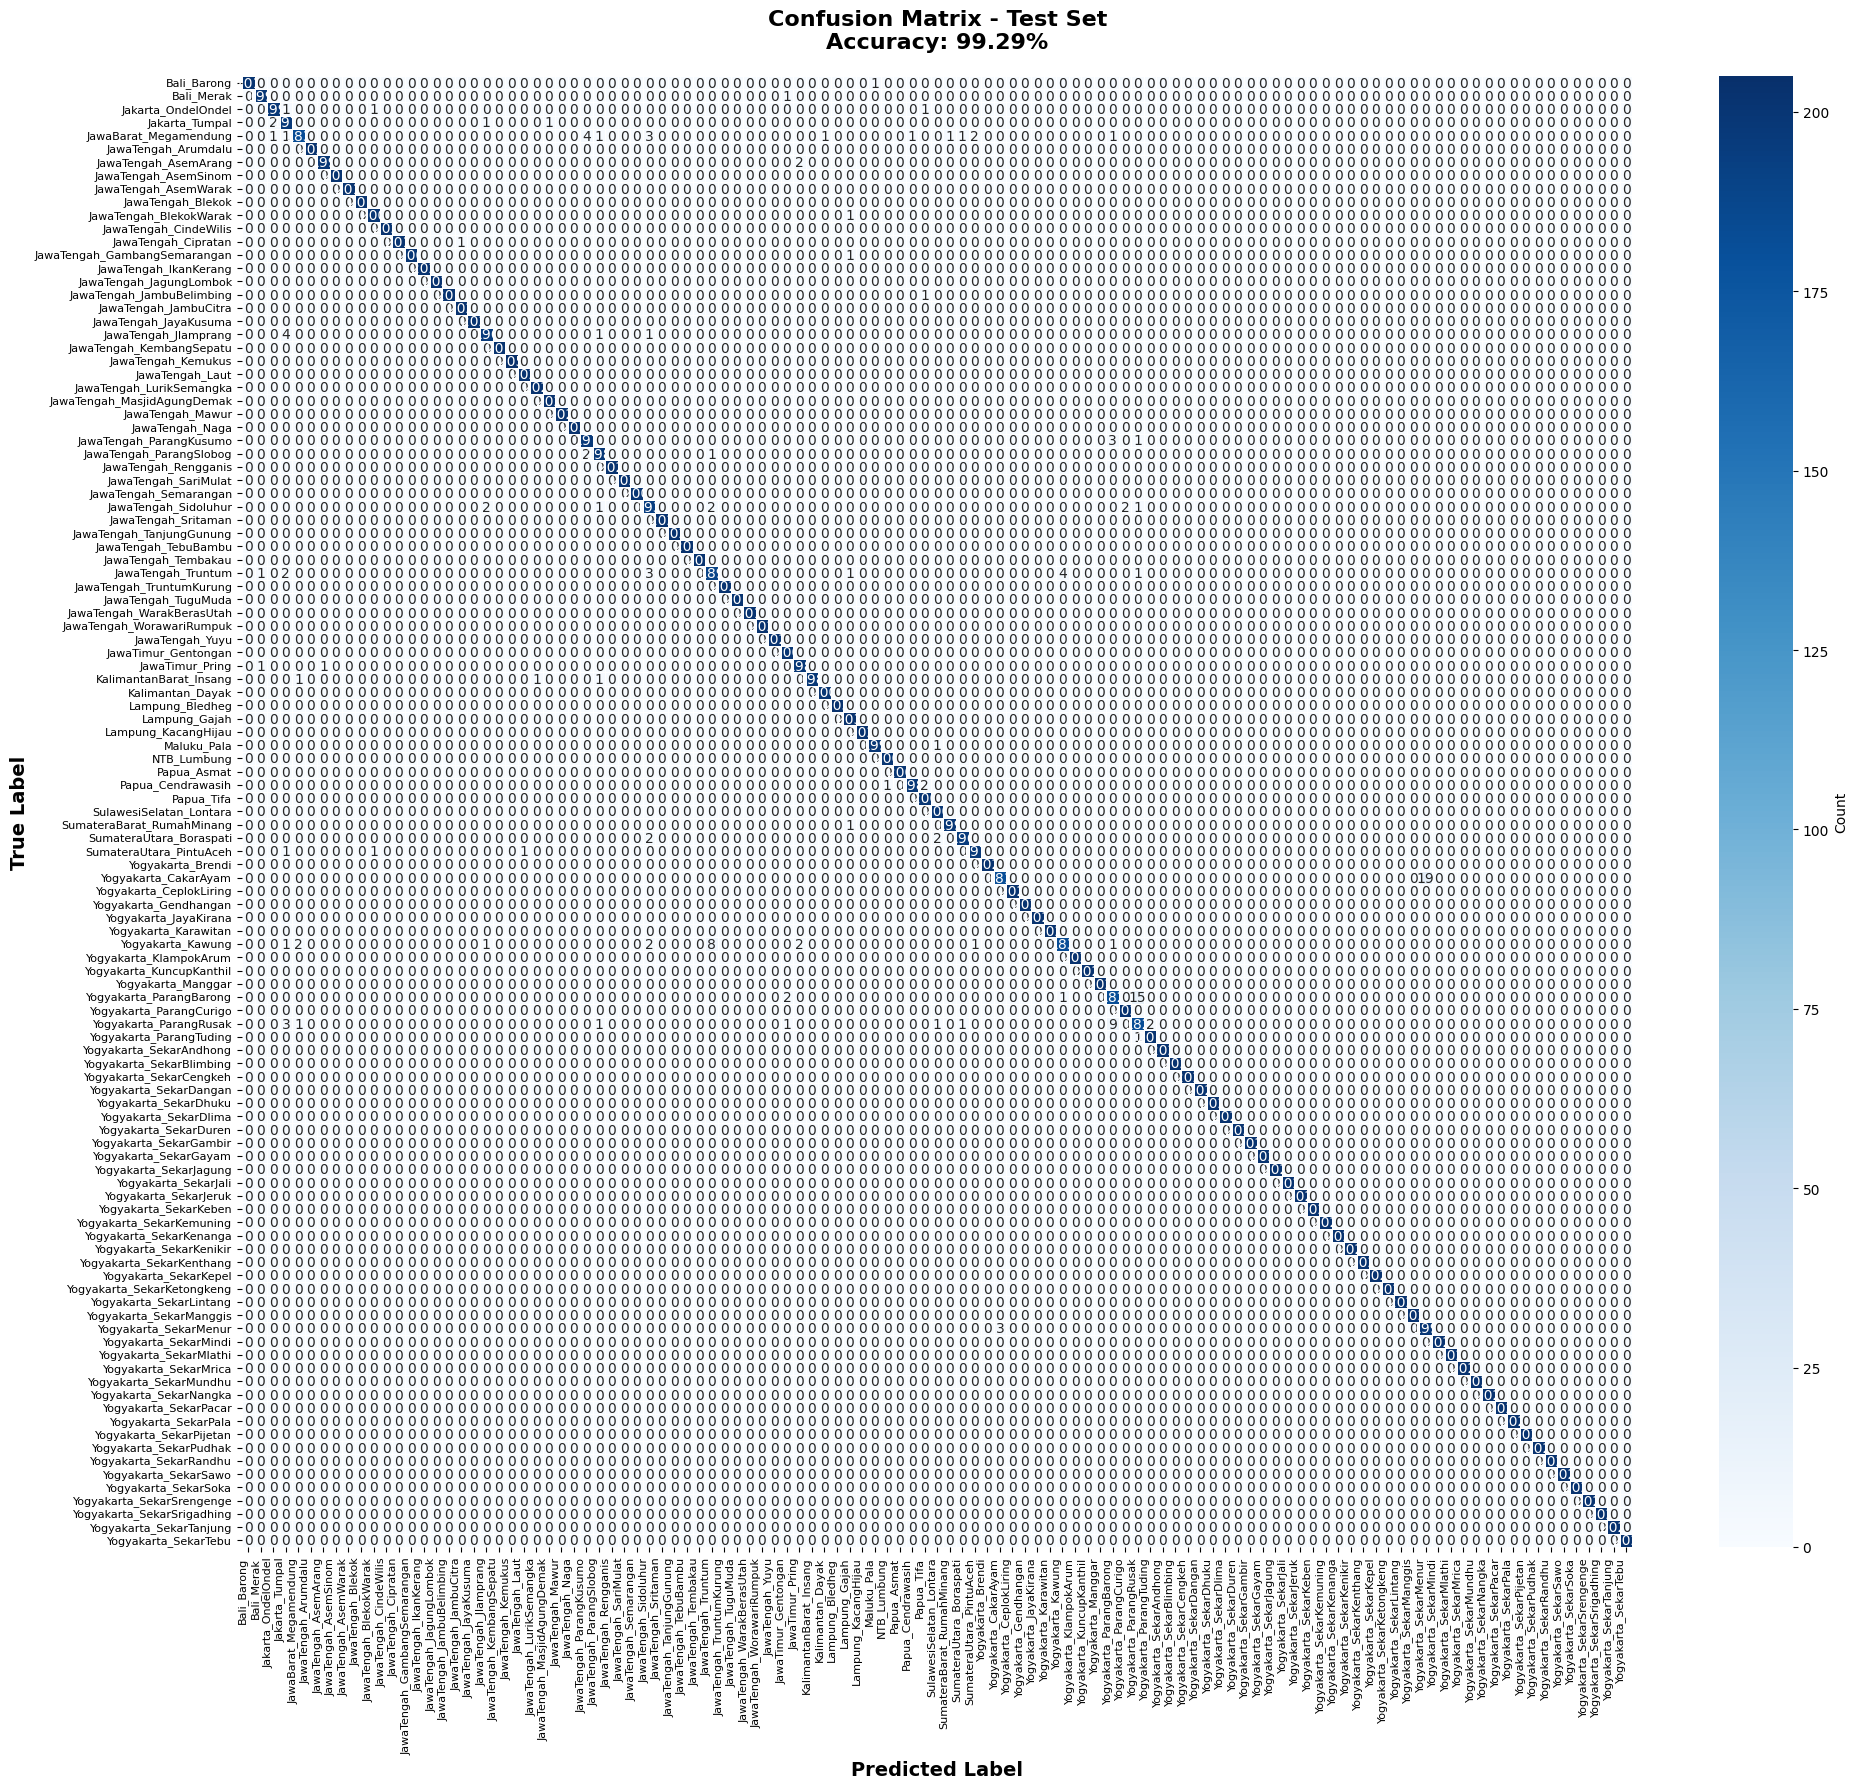

✅ Confusion matrix saved as 'confusion_matrix.png'


In [26]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot full confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(f'Confusion Matrix - Test Set\nAccuracy: {test_acc:.2f}%', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'")

## Per-Class Performance Analysis

In [27]:
# Detailed classification report
print("="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
report = classification_report(all_labels, all_predictions, 
                               target_names=class_names, 
                               digits=4, 
                               zero_division=0)
print(report)

# Save to file
with open('classification_report.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("CLASSIFICATION REPORT - VGG16 BATIK MODEL\n")
    f.write("="*70 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Split Ratio: {SELECTED_SPLIT}\n")
    f.write(f"Best Validation Accuracy: {best_acc:.2f}%\n")
    f.write(f"Test Accuracy: {test_acc:.4f}%\n")
    f.write(f"Total Training Time: {total_training_time/3600:.2f} hours\n\n")
    f.write(report)

print("\n✅ Classification report saved as 'classification_report.txt'")

DETAILED CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                 Bali_Barong     1.0000    0.9950    0.9975       202
                  Bali_Merak     0.9900    0.9950    0.9925       200
          Jakarta_OndelOndel     0.9851    0.9851    0.9851       202
              Jakarta_Tumpal     0.9381    0.9801    0.9586       201
       JawaBarat_Megamendung     0.9786    0.9150    0.9457       200
         JawaTengah_Arumdalu     1.0000    1.0000    1.0000       202
        JawaTengah_AsemArang     0.9950    0.9900    0.9925       201
        JawaTengah_AsemSinom     1.0000    1.0000    1.0000       201
        JawaTengah_AsemWarak     1.0000    1.0000    1.0000       201
           JawaTengah_Blekok     1.0000    1.0000    1.0000       201
      JawaTengah_BlekokWarak     0.9901    0.9950    0.9926       201
       JawaTengah_CindeWilis     1.0000    1.0000    1.0000       202
         JawaTengah_Cipratan     1.0000    0.9950    0.997

In [28]:
# Per-class accuracy visualization
class_accuracies = []
for i in range(num_classes):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        class_acc = (np.array(all_predictions)[mask] == i).sum() / mask.sum() * 100
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

# Create DataFrame for better analysis
df_performance = pd.DataFrame({
    'Class': class_names,
    'Accuracy (%)': class_accuracies,
    'Sample Count': [np.sum(np.array(all_labels) == i) for i in range(num_classes)]
})
df_performance = df_performance.sort_values('Accuracy (%)', ascending=False)

# Top 10 and Bottom 10 classes
print("\n" + "="*70)
print("TOP 10 PERFORMING CLASSES")
print("="*70)
print(df_performance.head(10).to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 10 PERFORMING CLASSES")
print("="*70)
print(df_performance.tail(10).to_string(index=False))

# Save to CSV
df_performance_full = df_performance.sort_values('Class')
df_performance_full.to_csv('per_class_performance.csv', index=False)
print("\n✅ Per-class performance saved as 'per_class_performance.csv'")


TOP 10 PERFORMING CLASSES
                      Class  Accuracy (%)  Sample Count
        JawaTengah_Arumdalu         100.0           202
       JawaTengah_AsemWarak         100.0           201
      JawaTengah_IkanKerang         100.0           202
      JawaTengah_CindeWilis         100.0           202
          JawaTengah_Blekok         100.0           201
       JawaTengah_AsemSinom         100.0           201
       JawaTengah_SariMulat         100.0           202
   JawaTengah_LurikSemangka         100.0           202
JawaTengah_MasjidAgungDemak         100.0           202
         JawaTengah_Kemukus         100.0           205

BOTTOM 10 PERFORMING CLASSES
                  Class  Accuracy (%)  Sample Count
         Jakarta_Tumpal     98.009950           201
SumateraUtara_Boraspati     98.000000           200
   JawaTengah_Jlamprang     97.029703           202
   JawaTengah_Sidoluhur     96.019900           201
     JawaTengah_Truntum     94.029851           201
  JawaBarat_Meg

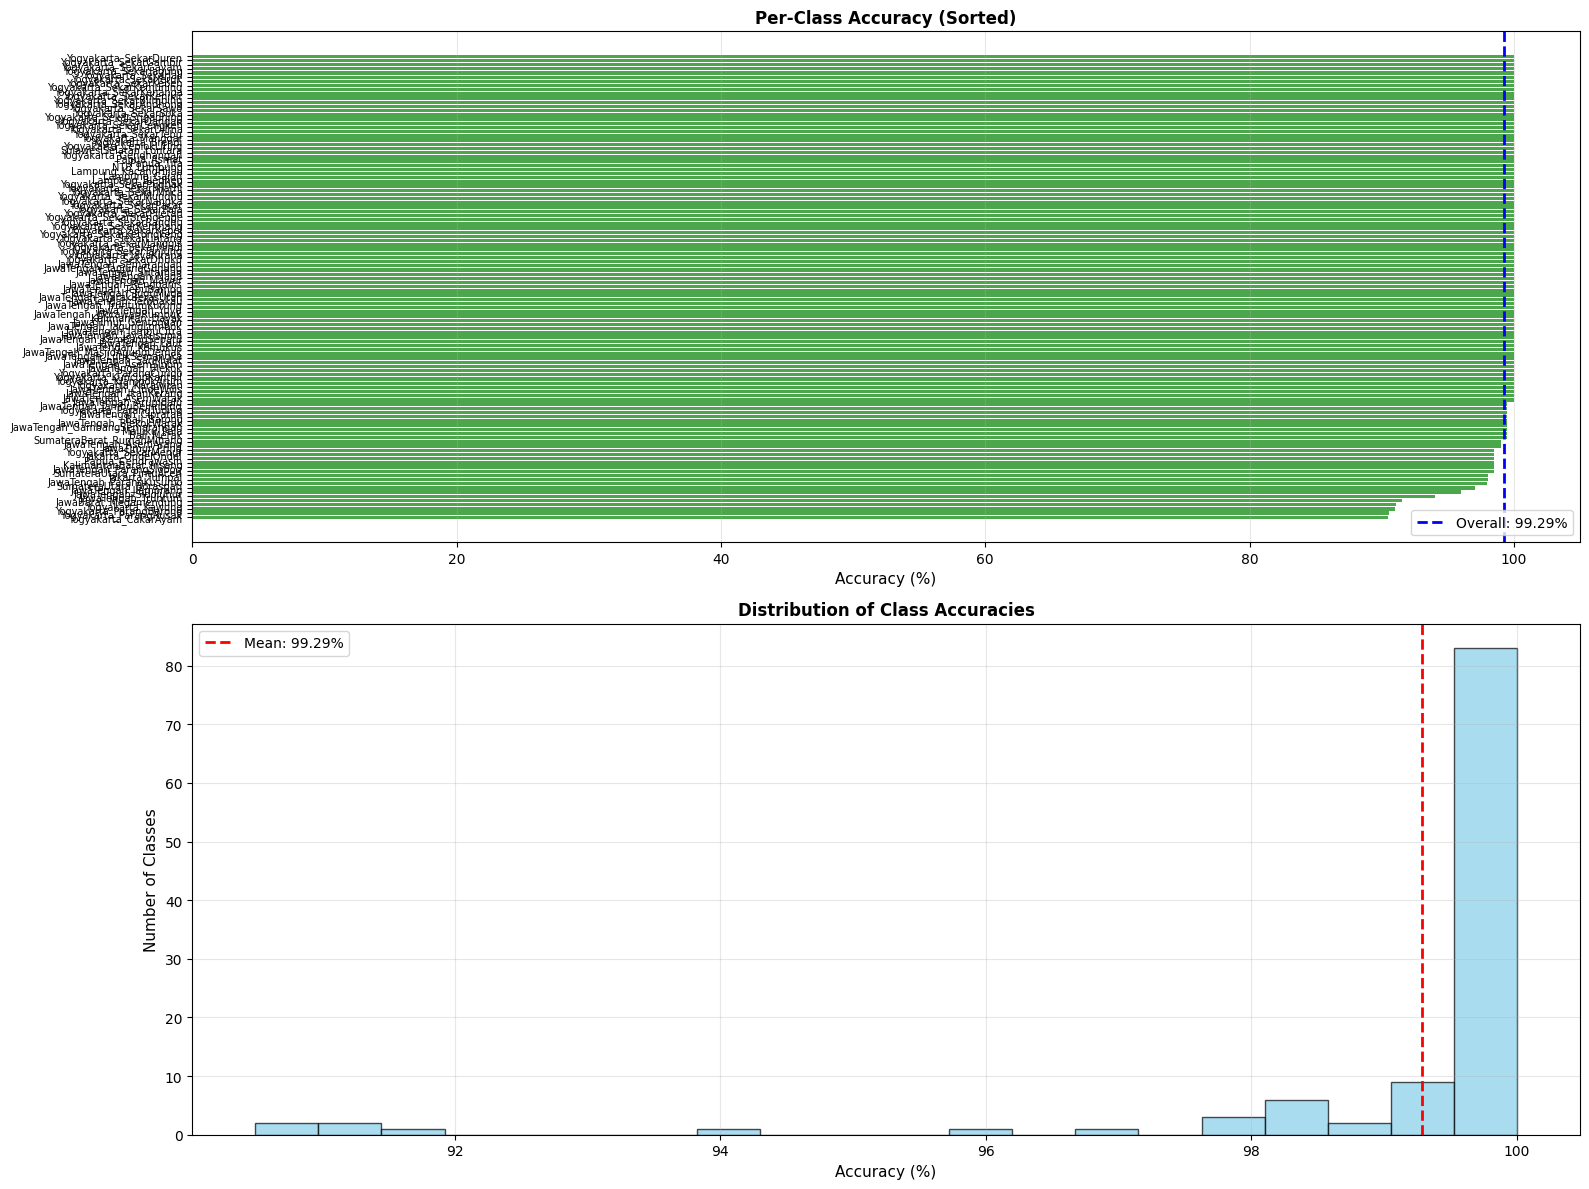

✅ Per-class accuracy plot saved as 'per_class_accuracy.png'


In [29]:
# Visualize per-class accuracy
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Bar plot - sorted by accuracy
df_sorted = df_performance.sort_values('Accuracy (%)', ascending=True)
colors = ['red' if x < 70 else 'orange' if x < 85 else 'green' for x in df_sorted['Accuracy (%)']]
axes[0].barh(range(len(df_sorted)), df_sorted['Accuracy (%)'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(df_sorted)))
axes[0].set_yticklabels(df_sorted['Class'], fontsize=7)
axes[0].set_xlabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Per-Class Accuracy (Sorted)', fontsize=12, fontweight='bold')
axes[0].axvline(x=test_acc, color='blue', linestyle='--', linewidth=2, label=f'Overall: {test_acc:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Histogram of accuracies
axes[1].hist(class_accuracies, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=test_acc, color='red', linestyle='--', linewidth=2, label=f'Mean: {test_acc:.2f}%')
axes[1].set_xlabel('Accuracy (%)', fontsize=11)
axes[1].set_ylabel('Number of Classes', fontsize=11)
axes[1].set_title('Distribution of Class Accuracies', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Per-class accuracy plot saved as 'per_class_accuracy.png'")

## Model Performance Summary Statistics

In [30]:
# Summary statistics
print("="*70)
print("MODEL PERFORMANCE SUMMARY FOR RESEARCH")
print("="*70)
print(f"\n{'DATASET INFORMATION':-^70}")
print(f"Total Classes: {num_classes}")
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Test Samples: {len(test_dataset)}")
print(f"Split Ratio: {SELECTED_SPLIT}")

print(f"\n{'TRAINING CONFIGURATION':-^70}")
print(f"Model Architecture: VGG16 (Pretrained on ImageNet)")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Initial Learning Rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Loss Function: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

print(f"\n{'TRAINING RESULTS':-^70}")
print(f"Total Epochs: {len(history['train_acc'])}")
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_acc:.4f}%")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}%")

print(f"\n{'TEST SET PERFORMANCE':-^70}")
print(f"Test Accuracy: {test_acc:.4f}%")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

print(f"\n{'TRAINING TIME ANALYSIS':-^70}")
print(f"Total Training Time: {total_training_time/3600:.2f} hours ({total_training_time/60:.2f} minutes)")
print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Fastest Epoch: {min(history['epoch_time']):.2f} seconds")
print(f"Slowest Epoch: {max(history['epoch_time']):.2f} seconds")
print(f"Test Inference Time: {test_time:.2f} seconds")
print(f"Inference Speed: {test_total/test_time:.2f} images/second")

print(f"\n{'PER-CLASS STATISTICS':-^70}")
print(f"Mean Class Accuracy: {np.mean(class_accuracies):.4f}%")
print(f"Std Class Accuracy: {np.std(class_accuracies):.4f}%")
print(f"Min Class Accuracy: {np.min(class_accuracies):.4f}%")
print(f"Max Class Accuracy: {np.max(class_accuracies):.4f}%")
print(f"Classes with >90% accuracy: {sum(1 for acc in class_accuracies if acc > 90)}/{num_classes}")
print(f"Classes with >80% accuracy: {sum(1 for acc in class_accuracies if acc > 80)}/{num_classes}")
print(f"Classes with <70% accuracy: {sum(1 for acc in class_accuracies if acc < 70)}/{num_classes}")

print(f"\n{'HARDWARE INFORMATION':-^70}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

print("="*70)

MODEL PERFORMANCE SUMMARY FOR RESEARCH

-------------------------DATASET INFORMATION--------------------------
Total Classes: 111
Training Samples: 66947
Validation Samples: 22360
Test Samples: 22378
Split Ratio: 60/20/20

------------------------TRAINING CONFIGURATION------------------------
Model Architecture: VGG16 (Pretrained on ImageNet)
Image Size: 224x224
Batch Size: 64
Initial Learning Rate: 0.001
Optimizer: Adam
Loss Function: CrossEntropyLoss
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

---------------------------TRAINING RESULTS---------------------------
Total Epochs: 30
Best Epoch: 30
Best Validation Accuracy: 99.2844%
Final Training Accuracy: 98.9320%
Final Validation Accuracy: 99.2844%

-------------------------TEST SET PERFORMANCE-------------------------
Test Accuracy: 99.2850%
Precision (weighted): 0.9929
Recall (weighted): 0.9929
F1-Score (weighted): 0.9928

------------------------TRAINING TIME ANALYSIS------------------------
Total Training Time: 1.81 hou

## Save Model & Configuration

In [31]:
# Save model weights
torch.save(model.state_dict(), 'vgg16_batik_weights.pth')

# Save class labels
with open('labels.txt', 'w') as f:
    for label in class_names:
        f.write(label + '\n')

# Save comprehensive configuration and results
config = {
    'model': 'VGG16',
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_classes': num_classes,
    'class_names': class_names,
    'split_ratio': SELECTED_SPLIT,
    'training': {
        'epochs': len(history['train_acc']),
        'best_epoch': best_epoch,
        'initial_lr': LEARNING_RATE,
        'optimizer': 'Adam',
        'scheduler': 'ReduceLROnPlateau',
        'total_time_hours': round(total_training_time / 3600, 2),
        'avg_epoch_time_seconds': round(avg_epoch_time, 2)
    },
    'results': {
        'best_val_acc': round(float(best_acc), 4),
        'final_train_acc': round(float(history['train_acc'][-1]), 4),
        'final_val_acc': round(float(history['val_acc'][-1]), 4),
        'test_acc': round(float(test_acc), 4),
        'test_precision': round(float(precision), 4),
        'test_recall': round(float(recall), 4),
        'test_f1': round(float(f1), 4),
        'inference_speed_imgs_per_sec': round(float(test_total/test_time), 2)
    },
    'class_statistics': {
        'mean_class_accuracy': round(float(np.mean(class_accuracies)), 4),
        'std_class_accuracy': round(float(np.std(class_accuracies)), 4),
        'min_class_accuracy': round(float(np.min(class_accuracies)), 4),
        'max_class_accuracy': round(float(np.max(class_accuracies)), 4)
    },
    'hardware': {
        'device': str(device),
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
        'cuda_version': str(torch.version.cuda) if torch.cuda.is_available() else 'N/A'
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save training history to CSV for further analysis
history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_acc']) + 1),
    'train_loss': history['train_loss'],
    'train_acc': history['train_acc'],
    'val_loss': history['val_loss'],
    'val_acc': history['val_acc'],
    'learning_rate': history['learning_rate'],
    'epoch_time_seconds': history['epoch_time']
})
history_df.to_csv('training_history.csv', index=False)

print("="*70)
print("ALL FILES SAVED FOR RESEARCH")
print("="*70)
print("\nModel Files:")
print("  vgg16_batik_best.pth (checkpoint with history)")
print("  vgg16_batik_weights.pth (weights only)")
print("\nConfiguration & Results:")
print("  model_config.json (comprehensive config)")
print("  labels.txt (class names)")
print("  classification_report.txt (detailed metrics)")
print("  per_class_performance.csv (per-class analysis)")
print("  training_history.csv (epoch-by-epoch data)")
print("\nVisualizations:")
print("  training_history_detailed.png (6 plots)")
print("  confusion_matrix.png")
print("  per_class_accuracy.png")
print("="*70)

ALL FILES SAVED FOR RESEARCH

Model Files:
  vgg16_batik_best.pth (checkpoint with history)
  vgg16_batik_weights.pth (weights only)

Configuration & Results:
  model_config.json (comprehensive config)
  labels.txt (class names)
  classification_report.txt (detailed metrics)
  per_class_performance.csv (per-class analysis)
  training_history.csv (epoch-by-epoch data)

Visualizations:
  training_history_detailed.png (6 plots)
  confusion_matrix.png
  per_class_accuracy.png
